# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data files will be in the canvas assignment, merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


# notes

 salary should be serpated by color, like a heatmap, slares wont be x and y axis tho
 shaped should be the cluster

need to figure out what features is the best to put on x and y scatter plot

so bsacilly need like skill performance levels and good high stats for the x and y

expierennt but theres a mathamatical way to do. use stat like points scored, minutes played or games played, rebounds 
these work well becase they have high distributiona dn varince beasucase they shows good from bad and makes better clusters
    
tool to show how features that show salaries well: correlation matrix, which shows how features are correlated with each other and with the target variable (salaries)
putting data on a chart to see how it moves in space. when slareis go up, which stats go up. run simple line?

if theres players at the top right but have low salraies then we want those guys

if there are players with high salaries but low stats then we want to avoid those guys


In [ ]:
# import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Data
salaries = pd.read_csv('2025_salaries.csv', header = 1, encoding = 'latin-1')
# the actual headers were in the second row of the csv file, so set header = 1
salaries.columns = ['Player', 'Team', 'Salary']
#change column names

nba = pd.read_csv('nba_2025.txt', sep=',', encoding = 'latin-1')
#this was a txt file not csv, but was still ceperated by commas, so set sep = ','

In [3]:
#Merging the datasets by the players name
merged = pd.merge(nba, salaries, on='Player', how = 'inner')
# went from salaries 471 and nba 643 down to merged having 524 rows bc there were dupliactes

In [4]:
#Drop variables that will not be needed or are duplicates
duplicates = merged[merged.duplicated(subset='Player', keep=False)]
#index then create a new dataframe with only the duplicates to show the duplicates
#there are 56 distinct players
#there are two cases for the duplcates:
   #1) a player was on more then one team during the season so thay had one row
   # for there combined data in 2TM, then two more rows for there spesfic stats on each spesfic team
   # 2) a player was on one team but when the datasets were merged there teams were listed differently
   # so they were not merged together and instead created two rows for the same player with the same stats but different team names
#my appraoch is to keep the first row for each player name beasuce teh 2TM row is alwasy first and
# the direct duplicates have teh same data in both rows so it does not matter which one i keep

In [5]:
#drop duplcaites by keeping first row for each player name
merged_dropped = merged.drop_duplicates(subset='Player', keep='first')


In [6]:
#check to see if there are any duplicates left
duplicates2 = merged_dropped[merged_dropped.duplicated(subset='Player', keep=False)]
#theres not any duplicates left

In [7]:
#print info to look at what rows need to be dropped and what columns types need to be changed
print(merged_dropped.columns)
print(merged_dropped.dtypes)
print(merged_dropped.isnull().sum())

Index(['Rk', 'Player', 'Age', 'Team_x', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Trp-Dbl', 'Awards', 'Player-additional', 'Team_y', 'Salary'],
      dtype='str')
Rk                   float64
Player                   str
Age                  float64
Team_x                   str
Pos                      str
G                    float64
GS                   float64
MP                   float64
FG                   float64
FGA                  float64
FG%                  float64
3P                   float64
3PA                  float64
3P%                  float64
2P                   float64
2PA                  float64
2P%                  float64
eFG%                 float64
FT                   float64
FTA                  float64
FT%                  float64
ORB                  float64
DRB                  float64
TRB             

In [8]:
#drop unneccesary columns and colmuns with missing values
df = merged_dropped.drop(columns=['Team_x', 'Player-additional', 'Awards', 'Team_y'])
#make salary numeric by getting rid of the $ and commas and changing the type to float
df['Salary'] = df['Salary'].str.replace('$', '').str.replace(',', '').astype(float)

print(df.isnull().sum())

Rk          0
Player      0
Age         0
Pos         0
G           0
GS          0
MP          0
FG          0
FGA         0
FG%         0
3P          0
3PA         0
3P%        20
2P          0
2PA         0
2P%         1
eFG%        0
FT          0
FTA         0
FT%         3
ORB         0
DRB         0
TRB         0
AST         0
STL         0
BLK         0
TOV         0
PF          0
PTS         0
Trp-Dbl     0
Salary      3
dtype: int64


In [9]:
#drop the rows with missing salary data since need to be no nulls for the modeling
df = df.dropna(subset=['Salary'])
#drop these columns beucase they are redundent anyway becuase its a percetage caluataled form data thats already there
df = df.drop(columns=['2P%','3P%','FT%'])


In [10]:
#check to see if there are any nulls left
print(df.isnull().sum())

Rk         0
Player     0
Age        0
Pos        0
G          0
GS         0
MP         0
FG         0
FGA        0
FG%        0
3P         0
3PA        0
2P         0
2PA        0
eFG%       0
FT         0
FTA        0
ORB        0
DRB        0
TRB        0
AST        0
STL        0
BLK        0
TOV        0
PF         0
PTS        0
Trp-Dbl    0
Salary     0
dtype: int64


In [11]:
# search for the best features to use for x and y based on high varience and coorelation
#looking at variation first
df[['PTS','AST','TRB','MP','STL','BLK']].var()

#so far pts and mp have the highest varience but want to also look at coorelation

PTS    110377.011157
AST      7536.503199
TRB     13336.261682
MP     267976.714866
STL       446.733535
BLK       346.129618
dtype: float64

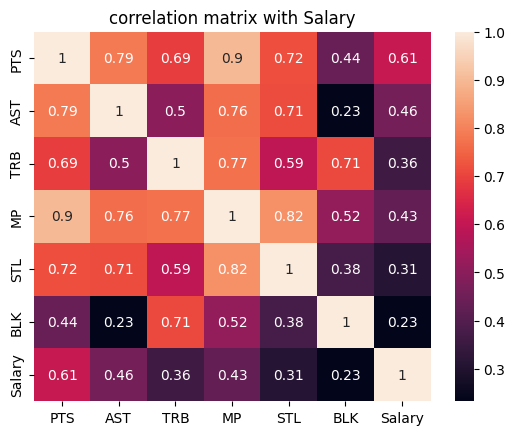

In [12]:
corrlation = df[['PTS','AST','TRB','MP','STL','BLK','Salary']].corr()

sns.heatmap(corrlation, annot=True) #shows number labels
plt.title("correlation matrix with Salary")
plt.show()

I chose PTS and AST because they have the highest correlation numbers with Salary (0.61 and 0.46). I didn't use MP even though it also had a higher correlation with Salary because it's 0.90 correlated with PTS, which is redundant.

In [13]:
#scale the data 
from sklearn.preprocessing import StandardScaler

features = df[['PTS','AST']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [14]:
#Run the clustering algo with your best guess for K

# Im gonna do K=4. I dont know much about basketball but maybe having a group of the best, the upper middle , the lower middle, adn the worst
# players will be a good start and then can adjust from there.
# first trying out players PTS poinst scored and AST assists to show how they score but also play as a team member.
# Initialize KMeans with K=3
model = KMeans(n_clusters=4, random_state=1)
# fit
model.fit(scaled_data)
# add the cluster labels to the data frame
df['cluster'] = model.labels_

In [15]:
#View the results

# this gives the avg points and assists for each cluster 
print(df.groupby("cluster")[["PTS", "AST"]].mean())
#this is important because it shows how the clusters are different 
# from each other and what the characteristics of each cluster are

#how many players are in each cluster
df["cluster"].value_counts()
#this shows how many players are in each cluster and if the clusters are balanced or not

                PTS         AST
cluster                        
0        450.892857   93.978571
1        133.321637   27.058480
2        826.358209  166.059701
3        976.666667  311.181818


cluster
1    171
0    140
2     67
3     33
Name: count, dtype: int64

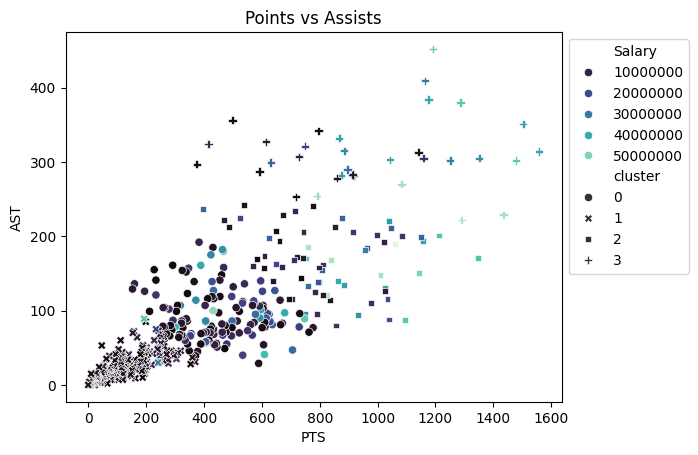

In [16]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

sns.scatterplot(data=df, x='PTS', y='AST', hue='Salary', style='cluster', palette='mako') #set the color to salar and the cluster shape to the cluster number
#looking for dark colors in the upper right corner to show the best players with the lowest salary and but high points and assists
plt.legend(bbox_to_anchor=(1, 1), loc=2) # move legend outside of the plot
plt.title('Points vs Assists')
plt.show()

In [ ]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores

#calculate the variance explained (how much of the total spread is explained by the clusters)
# total spread 
# this finds how far every point is from the average of the whole dataset
#get by finsing sum of the squared distance from each point to the mean of the whole dataset
total_ss_scaled = np.sum(scaled_data**2) 
# subtract the dpread inside hte clusters
# .inertia_ is the distance points still have from their cluster centers
between_SSE = (total_ss_scaled - model.inertia_)
#get the percentage of variance explained
# if low % then the clusters are not doing a good job of grouping similar 
# points together and there is still a lot of spread within the clusters
#if its a high % then the clusters are doing a good job of grouping similar points
#  together and there is not much spread within the clusters
var_explained = between_SSE / total_ss_scaled
print(var_explained)
# 82.39% is pretty good, it means that the clusters are doing a good job of grouping 
# similar points together and there is not much spread within the clusters

#calculate silhouette score
from sklearn.metrics import silhouette_score
#i did not really know what this meant but now i understnad it as a way to measure how well and distincly
# the clusters are separated from each other and how well the points are grouped together within the clusters
silhouette = silhouette_score(scaled_data, model.labels_)
print(silhouette)
#0.46117302322124953
# can be from -1 to 1
#this is also a pretty good number because it is close to 1 which means that theres clear seperation btw
# the cluster and the clusters themselves are grouped together well

0.8239897259346388
0.46117302322124953


In [18]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

inertias = []

#run k means in a loop testing for 2 to 15 clusters and save the inertia for each k in a list that can be plotted after
for k in range(2, 15): # 2 to 15 clusters
    model2 = KMeans(n_clusters=k, random_state=2)
    model2.fit(scaled_data)
    
    inertias.append(model2.inertia_)

#make the data into a df that shows teh k values and then inerita in the same row so that it can be plotted
elbow = pd.DataFrame({"k": range(2, 15), "inertias": inertias})



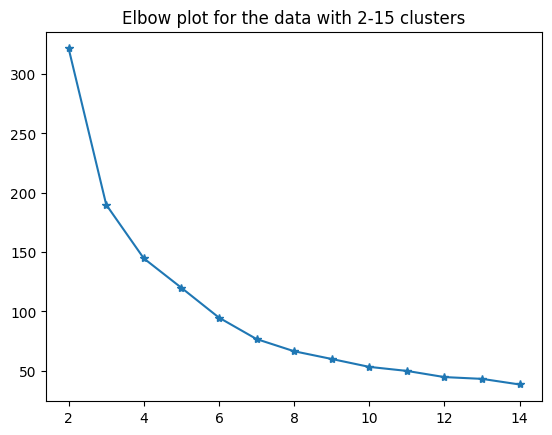

In [19]:
#Visualize the results of the elbow method

#plot the elbow plot
plt.plot(elbow['k'], elbow["inertias"],  marker="*") # marker is just to make the points more visible
plt.title('Elbow plot for the data with 2-15 clusters')
plt.show()

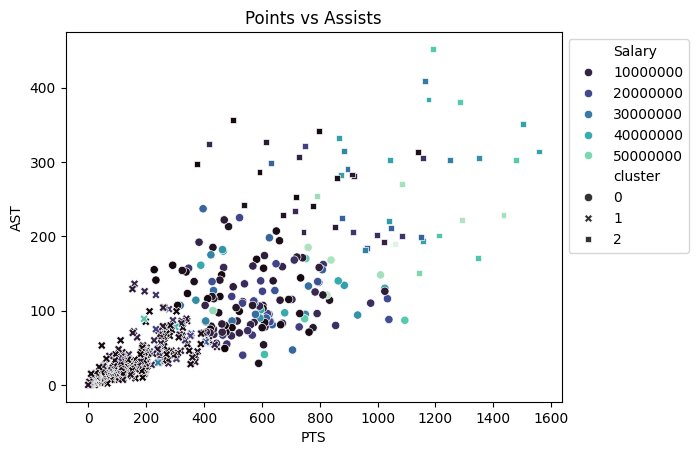

In [20]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
#from the elbox plot it looks like the recommened k value is 3. I had already done that before

#use same methods as before: 

#make copy
df2 = df.copy()
features = df2[['PTS','AST']]

scaler = StandardScaler()
scaled_data2 = scaler.fit_transform(features)

#kmeans with k = 3
model2 = KMeans(n_clusters=3, random_state=1)
model2.fit(scaled_data2)
df2['cluster'] = model2.labels_

#plot
sns.scatterplot(data=df2, x='PTS', y='AST', hue='Salary', style='cluster', palette='mako')
plt.legend(bbox_to_anchor=(1, 1), loc=2)
plt.title('Points vs Assists')
plt.show()


In [ ]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores

#use same methods as before
total_ss_scaled2 = np.sum(scaled_data2**2) 
between_SSE2 = (total_ss_scaled2 - model2.inertia_)
var_explained2 = between_SSE2 / total_ss_scaled2
print(var_explained2)
# 76.89% is still pretty good. it is lower then before with 4 clusters but that is expected 
# because with fewer clusters there is more spread within the clusters and less variance explained 
# but it is still a good number because it means that the clusters are still doing a good job of grouping 
# similar points together and there is not much spread within the clusters


silhouette2 = silhouette_score(scaled_data2, model2.labels_)
print(silhouette2)
#0.5008966626218551
#this is also a pretty good number. it is higher then before with 4 clusters 
# because with fewer clusters there is more clear seperation
# btw the clusters and the clusters themselves are grouped together better

0.7689297766208653
0.5008966626218551


best:
                Player    PTS    AST     Salary
230        Jamal Shead  375.0  297.0  1955377.0
63   Russell Westbrook  796.0  342.0  2296274.0
88    Collin Gillespie  718.0  253.0  2296274.0
134        Cam Spencer  592.0  287.0  2537989.0
164     Isaiah Collier  499.0  356.0  2638200.0
worst:
               Player    PTS   AST      Salary
472      Bradley Beal   49.0  10.0  59020270.0
215     Anthony Davis  407.0  56.0  54126450.0
347        Trae Young  193.0  89.0  45999660.0
274  Domantas Sabonis  301.0  78.0  42336000.0
fine:              Player    PTS    AST     Salary
177  Maxime Raynaud  472.0   49.0  1272870.0
109    Jaylen Wells  629.0   86.0  1955377.0
186   Pelle Larsson  461.0  148.0  1955377.0
206    Quinten Post  422.0   75.0  1955377.0


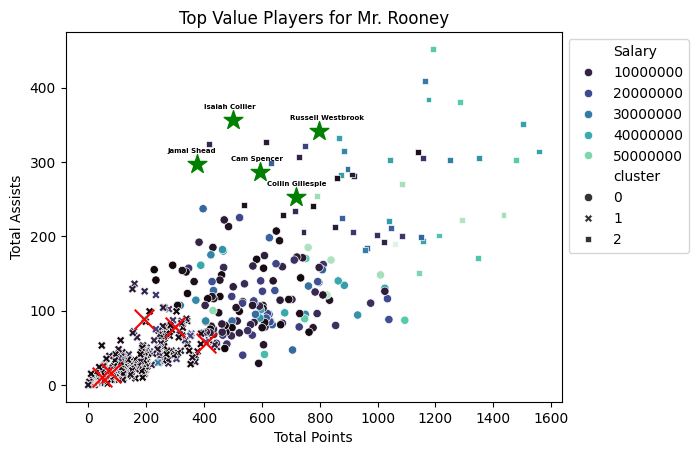

In [36]:
#Use the model to select players for Mr. Rooney to consider

#to do this im going to look in just cluster group 2 which shows the best players with the high points and assists
#then i want to sort it by slary to show the players getting paid the least but still have good points and assists
#filter for just cluster 2
players = df2[df2['cluster'] == 2]
#sort by salary to show lowest salary players first
recs = players.sort_values(by='Salary', ascending=True)
#show top 5
print(f"best:\n{recs[['Player', 'PTS', 'AST', 'Salary']].head(5)}")

#repet steps for other clusters:

# not good choises as these are the players that get paid the most but are in teh worst cluster
bad_cluster = df2[df2['cluster'] == 1]  
not_good = bad_cluster.sort_values(by='Salary', ascending=False)
print(f"worst:\n{not_good[['Player', 'PTS', 'AST', 'Salary']].head(4)}")

# these guys are ok middle men that play find but sitll have a lower salary
mid_cluster = df2[df2['cluster'] == 0]  
okay = mid_cluster.sort_values(by='Salary', ascending=True)
print(f"fine: {okay[['Player', 'PTS', 'AST', 'Salary']].head(4)}")


#plot them on teh graph to stand out to see where they stand visually compared to others in teh cluster
top_5 = recs.head(5) #new df with just the top 5 players
bottom_5 = not_good.head(5) #new df with just the bottom 5 players

#plot base grpah
plot = sns.scatterplot(data=df2, x='PTS', y='AST', hue='Salary', style='cluster', palette='mako')

# overlay the top 5 players and bottom 5 to make them stand out
# use a star marker and make them much bigger (s=200)
plt.scatter(top_5['PTS'], top_5['AST'], color='green', marker='*', s=200)
plt.scatter(bottom_5['PTS'], bottom_5['AST'], color='red', marker='x', s=200)


plt.legend(bbox_to_anchor=(1, 1), loc=2)
plt.title('Top Value Players for Mr. Rooney')
plt.xlabel('Total Points')
plt.ylabel('Total Assists')

# add labels for all top 5 players to easly identify who is who on the graph
for i in range(len(top_5)):
    plt.text(
        x=top_5.iloc[i]['PTS'] - 100, # move text more to the left
        y=top_5.iloc[i]['AST'] +15,      # move text up a little
        s=top_5.iloc[i]['Player'],   # the actual name
        fontsize=5, 
        fontweight='bold',
        color='black'
    )


plt.show()

 I started by looking at the top 10 but the salaries got expensive pretty fast, by player 10 we were already at $5M which made it harder to argue they were underpaid.
 So I cut it to top 5 since they all come in under $2.7M which feels like a much cleaner cutoff for "good value" players.

 My top two picks would be **Russell Westbrook** and **Isaiah Collier**

Two players that shouls definitly not be chosen are **Bradley Beal** and **Anthony Davis**

**Jaylen Wells** and **Pelle Larsson** are decent backup options

Write up the results in a separate notebook with supporting visualizations and 
an overview of how and why you made the choices you did. This should be at least 
500 words and should be written for a non-technical audience.

# Explination and player choices are in the Writeup.py file

